# 00 — Simulate AML Transactions

Generate synthetic AML transaction data with **configurable laundering patterns**.
Outputs the **three CSV files** expected by notebook 01 (`../demodata/`):

| File | Columns |
|------|----------|
| `party.csv` | `partyId, partyType` |
| `transactions.csv` | `tran_id, tx_type, base_amt, tran_timestamp, src, dst` |
| `alert_transactions.csv` | `alert_id, alert_type, is_sar, tran_id` |

### 6 Laundering Patterns Injected
1. **FAN_OUT** — 1 sender → many receivers
2. **FAN_IN** — many senders → 1 receiver
3. **CYCLE** — A→B→C→A circular flows
4. **SCATTER_GATHER** — spread then collect
5. **GATHER_SCATTER** — collect then spread
6. **STRUCTURING** — many small txns below threshold

### Alternative
Use `00_map_external_data.ipynb` if you have an external dataset (e.g., SAML-D).

In [1]:
import os
import re
import hashlib
from datetime import datetime, timedelta
from uuid import uuid4

import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════════
#  CONFIGURATION
# ═══════════════════════════════════════════════════════════

SEED = 42
OUTPUT_DIR = os.path.join("..", "demodata")

# ── Party ──
NUM_PARTIES = 7_500
ORG_FRACTION = 0.50       # 50% Organization, 50% Individual

# ── Normal transactions ──
NUM_NORMAL_TXNS = 430_000
AMOUNT_MU = 6.2           # lognormal mean param → exp(6.2) ≈ $493
AMOUNT_SIGMA = 0.4        # lognormal std
AMOUNT_MIN = 40.0
AMOUNT_MAX = 3_000.0

TX_TYPE_WEIGHTS = {
    "TRANSFER-Mutual":     0.31,
    "TRANSFER-FanOut":     0.26,
    "TRANSFER-Forward":    0.22,
    "TRANSFER-Periodical": 0.19,
    "TRANSFER-FanIn":      0.02,
}

DATE_START = datetime(2020, 1, 1)
DATE_END = datetime(2021, 12, 20)

# ── Laundering patterns ──
NUM_FAN_OUT = 15
NUM_FAN_IN = 15
NUM_CYCLE = 25
NUM_SCATTER_GATHER = 20
NUM_GATHER_SCATTER = 20
NUM_STRUCTURING = 5

FAN_MIN_LEGS = 4          # min receivers/senders in fan patterns
FAN_MAX_LEGS = 8
SCATTER_GATHER_FAN_SIZE = 5  # intermediaries in scatter/gather
STRUCTURING_NUM_TXNS = 15    # small txns per structuring case
STRUCTURING_AMT_MIN = 7_000  # just below $10K threshold
STRUCTURING_AMT_MAX = 9_500
PATTERN_AMT_MIN = 500
PATTERN_AMT_MAX = 3_000

rng = np.random.default_rng(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Seed: {SEED}")
print(f"Output: {os.path.abspath(OUTPUT_DIR)}")
print(f"Parties: {NUM_PARTIES:,}  Normal txns: {NUM_NORMAL_TXNS:,}")
total_patterns = NUM_FAN_OUT + NUM_FAN_IN + NUM_CYCLE + NUM_SCATTER_GATHER + NUM_GATHER_SCATTER + NUM_STRUCTURING
print(f"Pattern groups: {total_patterns} (fan_out={NUM_FAN_OUT}, fan_in={NUM_FAN_IN}, cycle={NUM_CYCLE}, scatter_gather={NUM_SCATTER_GATHER}, gather_scatter={NUM_GATHER_SCATTER}, structuring={NUM_STRUCTURING})")

Seed: 42
Output: /home/adnoman/projects/aml_gan/amle2e/demodata
Parties: 7,500  Normal txns: 430,000
Pattern groups: 100 (fan_out=15, fan_in=15, cycle=25, scatter_gather=20, gather_scatter=20, structuring=5)


---
## 1. Party Generation

In [2]:
def generate_parties(num_parties, org_fraction, seed):
    """Generate party DataFrame with 8-char hex IDs."""
    party_ids = []
    for i in range(num_parties):
        h = hashlib.md5(f"sim_{i}_{seed}".encode()).hexdigest()[:8]
        party_ids.append(h)
    
    # Collision check
    unique = set(party_ids)
    if len(unique) < len(party_ids):
        raise ValueError(f"Hash collision: {len(party_ids) - len(unique)} duplicates!")
    
    n_org = int(num_parties * org_fraction)
    types = ["Organization"] * n_org + ["Individual"] * (num_parties - n_org)
    rng.shuffle(types)
    
    return pd.DataFrame({"partyId": party_ids, "partyType": types})

party_df = generate_parties(NUM_PARTIES, ORG_FRACTION, SEED)
party_ids = party_df["partyId"].tolist()

print(f"Generated {len(party_df):,} parties")
print(f"  Organization: {(party_df['partyType'] == 'Organization').sum():,}")
print(f"  Individual:   {(party_df['partyType'] == 'Individual').sum():,}")
print(f"  Sample IDs:   {party_ids[:5]}")

Generated 7,500 parties
  Organization: 3,750
  Individual:   3,750
  Sample IDs:   ['b800b2bf', 'c5dccde2', '34cdefef', 'c1bfb464', 'c613c146']


---
## 2. Normal Transaction Generation

Power-law degree via Zipf sampling. Lognormal amounts.

In [3]:
def generate_normal_transactions(party_ids, num_txns, config_rng):
    """Generate normal (non-laundering) transactions."""
    n_parties = len(party_ids)
    
    # Source/dest via Zipf (power-law degree distribution)
    src_idx = config_rng.zipf(a=1.5, size=num_txns) % n_parties
    dst_idx = config_rng.zipf(a=1.3, size=num_txns) % n_parties
    
    # Fix self-loops
    self_loops = src_idx == dst_idx
    dst_idx[self_loops] = (dst_idx[self_loops] + 1) % n_parties
    
    src = [party_ids[i] for i in src_idx]
    dst = [party_ids[i] for i in dst_idx]
    
    # Amounts: lognormal
    amounts = config_rng.lognormal(AMOUNT_MU, AMOUNT_SIGMA, size=num_txns)
    amounts = np.clip(amounts, AMOUNT_MIN, AMOUNT_MAX).round(2)
    
    # tx_type: weighted choice
    tx_types = list(TX_TYPE_WEIGHTS.keys())
    tx_probs = list(TX_TYPE_WEIGHTS.values())
    tx_probs = np.array(tx_probs) / sum(tx_probs)  # normalize
    tx_type_arr = config_rng.choice(tx_types, size=num_txns, p=tx_probs)
    
    # Timestamps: uniform random days, sorted
    total_days = (DATE_END - DATE_START).days
    day_offsets = np.sort(config_rng.integers(0, total_days, size=num_txns))
    timestamps = [
        (DATE_START + timedelta(days=int(d))).strftime("%Y-%m-%dT%H:%M:%S.000Z")
        for d in day_offsets
    ]
    
    return pd.DataFrame({
        "tx_type": tx_type_arr,
        "base_amt": amounts,
        "tran_timestamp": timestamps,
        "src": src,
        "dst": dst,
        "_pattern_id": None,  # not a pattern
    })

normal_txns = generate_normal_transactions(party_ids, NUM_NORMAL_TXNS, rng)
print(f"Generated {len(normal_txns):,} normal transactions")
print(f"Amount: min=${normal_txns['base_amt'].min():.2f}, max=${normal_txns['base_amt'].max():.2f}, mean=${normal_txns['base_amt'].mean():.2f}")
print(f"tx_type distribution:\n{normal_txns['tx_type'].value_counts().to_string()}")

Generated 430,000 normal transactions
Amount: min=$79.97, max=$2929.49, mean=$533.77
tx_type distribution:
tx_type
TRANSFER-Mutual        133674
TRANSFER-FanOut        111693
TRANSFER-Forward        94064
TRANSFER-Periodical     81942
TRANSFER-FanIn           8627


---
## 3. Laundering Pattern Injectors

Each injector returns `(txn_rows, alert_rows)` — one alert per laundering transaction.

In [4]:
hub_used = set()  # track used hub nodes across patterns

def _pick_parties(n, exclude=None):
    """Pick n fresh party IDs, preferring unused hubs."""
    pool = [p for p in party_ids if p not in (exclude or set()) and p not in hub_used]
    if len(pool) < n:
        pool = [p for p in party_ids if p not in (exclude or set())]
    chosen = rng.choice(pool, size=n, replace=False).tolist()
    return chosen

def _random_ts():
    """Random timestamp in the date range."""
    days = int((DATE_END - DATE_START).days)
    offset = rng.integers(0, days)
    hours = rng.integers(0, 24)
    minutes = rng.integers(0, 60)
    dt = DATE_START + timedelta(days=int(offset), hours=int(hours), minutes=int(minutes))
    return dt

def _ts_str(dt):
    """Format datetime to ISO 8601 string."""
    return dt.strftime("%Y-%m-%dT%H:%M:%S.000Z")

def _pattern_amt():
    """Random amount for fan/cycle patterns."""
    return round(float(rng.uniform(PATTERN_AMT_MIN, PATTERN_AMT_MAX)), 2)


def inject_fan_out(alert_id):
    """1 sender → N receivers."""
    n_legs = int(rng.integers(FAN_MIN_LEGS, FAN_MAX_LEGS + 1))
    parties = _pick_parties(1 + n_legs)
    sender = parties[0]
    hub_used.add(sender)
    receivers = parties[1:]
    
    base_ts = _random_ts()
    txn_rows, alert_rows = [], []
    
    for i, recv in enumerate(receivers):
        pid = str(uuid4())
        ts = base_ts + timedelta(hours=int(rng.integers(0, 72)))
        txn_rows.append({
            "tx_type": "TRANSFER-FanOut", "base_amt": _pattern_amt(),
            "tran_timestamp": _ts_str(ts), "src": sender, "dst": recv, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "fan_out", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


def inject_fan_in(alert_id):
    """N senders → 1 receiver."""
    n_legs = int(rng.integers(FAN_MIN_LEGS, FAN_MAX_LEGS + 1))
    parties = _pick_parties(1 + n_legs)
    receiver = parties[0]
    hub_used.add(receiver)
    senders = parties[1:]
    
    base_ts = _random_ts()
    txn_rows, alert_rows = [], []
    
    for sender in senders:
        pid = str(uuid4())
        ts = base_ts + timedelta(hours=int(rng.integers(0, 72)))
        txn_rows.append({
            "tx_type": "TRANSFER-FanIn", "base_amt": _pattern_amt(),
            "tran_timestamp": _ts_str(ts), "src": sender, "dst": receiver, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "fan_in", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


def inject_cycle(alert_id):
    """A → B → C → A (3-node cycle)."""
    parties = _pick_parties(3)
    a, b, c = parties
    
    base_ts = _random_ts()
    base_amt = _pattern_amt()
    txn_rows, alert_rows = [], []
    
    for i, (s, d) in enumerate([(a, b), (b, c), (c, a)]):
        pid = str(uuid4())
        ts = base_ts + timedelta(hours=i * int(rng.integers(2, 12)))
        amt = round(base_amt * float(rng.uniform(0.90, 1.10)), 2)  # within 10%
        txn_rows.append({
            "tx_type": "TRANSFER-Forward", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": s, "dst": d, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "cycle", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


def inject_scatter_gather(alert_id):
    """Source → [N intermediaries] → Collector."""
    n = SCATTER_GATHER_FAN_SIZE
    parties = _pick_parties(2 + n)  # source + N mids + collector
    source = parties[0]
    collector = parties[1]
    hub_used.update([source, collector])
    intermediaries = parties[2:]
    
    base_ts = _random_ts()
    txn_rows, alert_rows = [], []
    
    # Phase 1: source → intermediaries (fan-out)
    phase1_amounts = []
    for mid in intermediaries:
        pid = str(uuid4())
        ts = base_ts + timedelta(hours=int(rng.integers(0, 24)))
        amt = _pattern_amt()
        phase1_amounts.append(amt)
        txn_rows.append({
            "tx_type": "TRANSFER-FanOut", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": source, "dst": mid, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "scatter_gather", "is_sar": "true", "_pattern_id": pid})
    
    # Phase 2: intermediaries → collector (fan-in, 1-5 days later, 90-95% amount)
    for i, mid in enumerate(intermediaries):
        pid = str(uuid4())
        ts = base_ts + timedelta(days=int(rng.integers(1, 6)), hours=int(rng.integers(0, 24)))
        amt = round(phase1_amounts[i] * float(rng.uniform(0.90, 0.95)), 2)
        txn_rows.append({
            "tx_type": "TRANSFER-FanIn", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": mid, "dst": collector, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "scatter_gather", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


def inject_gather_scatter(alert_id):
    """[N sources] → Hub → [M destinations]."""
    n_in = SCATTER_GATHER_FAN_SIZE
    n_out = SCATTER_GATHER_FAN_SIZE
    parties = _pick_parties(1 + n_in + n_out)
    hub = parties[0]
    hub_used.add(hub)
    sources = parties[1:1 + n_in]
    destinations = parties[1 + n_in:]
    
    base_ts = _random_ts()
    txn_rows, alert_rows = [], []
    
    # Phase 1: sources → hub (fan-in)
    total_gathered = 0
    for src in sources:
        pid = str(uuid4())
        ts = base_ts + timedelta(hours=int(rng.integers(0, 48)))
        amt = _pattern_amt()
        total_gathered += amt
        txn_rows.append({
            "tx_type": "TRANSFER-FanIn", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": src, "dst": hub, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "gather_scatter", "is_sar": "true", "_pattern_id": pid})
    
    # Phase 2: hub → destinations (fan-out, 2-7 days later)
    per_dest = total_gathered * 0.92 / n_out  # 8% "fee" retained
    for dst in destinations:
        pid = str(uuid4())
        ts = base_ts + timedelta(days=int(rng.integers(2, 8)), hours=int(rng.integers(0, 24)))
        amt = round(per_dest * float(rng.uniform(0.90, 1.10)), 2)
        txn_rows.append({
            "tx_type": "TRANSFER-FanOut", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": hub, "dst": dst, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "gather_scatter", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


def inject_structuring(alert_id):
    """1 sender → 1-2 receivers, many small txns below $10K threshold."""
    n_recv = int(rng.integers(1, 3))  # 1 or 2 receivers
    parties = _pick_parties(1 + n_recv)
    sender = parties[0]
    hub_used.add(sender)
    receivers = parties[1:]
    
    base_ts = _random_ts()
    txn_rows, alert_rows = [], []
    
    for i in range(STRUCTURING_NUM_TXNS):
        pid = str(uuid4())
        recv = receivers[i % len(receivers)]
        ts = base_ts + timedelta(days=int(rng.integers(0, 15)), hours=int(rng.integers(8, 18)))
        amt = round(float(rng.uniform(STRUCTURING_AMT_MIN, STRUCTURING_AMT_MAX)), 2)
        txn_rows.append({
            "tx_type": "TRANSFER-Periodical", "base_amt": amt,
            "tran_timestamp": _ts_str(ts), "src": sender, "dst": recv, "_pattern_id": pid,
        })
        alert_rows.append({"alert_id": alert_id, "alert_type": "structuring", "is_sar": "true", "_pattern_id": pid})
    
    return txn_rows, alert_rows


print("Pattern injectors defined: fan_out, fan_in, cycle, scatter_gather, gather_scatter, structuring")

Pattern injectors defined: fan_out, fan_in, cycle, scatter_gather, gather_scatter, structuring


---
## 4. Inject All Patterns

In [5]:
all_pattern_txns = []
all_alert_rows = []
alert_counter = 1  # alert_id starts at 1

pattern_schedule = [
    ("fan_out",         inject_fan_out,         NUM_FAN_OUT),
    ("fan_in",          inject_fan_in,          NUM_FAN_IN),
    ("cycle",           inject_cycle,           NUM_CYCLE),
    ("scatter_gather",  inject_scatter_gather,  NUM_SCATTER_GATHER),
    ("gather_scatter",  inject_gather_scatter,  NUM_GATHER_SCATTER),
    ("structuring",     inject_structuring,      NUM_STRUCTURING),
]

for name, injector, count in pattern_schedule:
    pattern_txn_count = 0
    for _ in range(count):
        txn_rows, alert_rows = injector(alert_counter)
        all_pattern_txns.extend(txn_rows)
        all_alert_rows.extend(alert_rows)
        pattern_txn_count += len(txn_rows)
        alert_counter += 1
    print(f"  {name:20s}: {count:3d} groups, {pattern_txn_count:5d} transactions")

print(f"\nTotal pattern transactions: {len(all_pattern_txns):,}")
print(f"Total alert rows:           {len(all_alert_rows):,}")
print(f"Hub nodes used:             {len(hub_used):,}")

  fan_out             :  15 groups,    96 transactions
  fan_in              :  15 groups,    98 transactions
  cycle               :  25 groups,    75 transactions
  scatter_gather      :  20 groups,   200 transactions
  gather_scatter      :  20 groups,   200 transactions
  structuring         :   5 groups,    75 transactions

Total pattern transactions: 744
Total alert rows:           744
Hub nodes used:             95


---
## 5. Assembly & ID Assignment

In [6]:
# Combine normal + pattern transactions
pattern_df = pd.DataFrame(all_pattern_txns)
all_txns = pd.concat([normal_txns, pattern_df], ignore_index=True)

# Sort by timestamp
all_txns = all_txns.sort_values("tran_timestamp").reset_index(drop=True)

# Assign non-contiguous tran_ids (spread factor ~2.4x like existing data)
total = len(all_txns)
id_pool = sorted(rng.choice(range(1, int(total * 2.4)), size=total, replace=False))
all_txns["tran_id"] = id_pool

# Build alert_transactions by joining on _pattern_id
alert_df_raw = pd.DataFrame(all_alert_rows)
pattern_id_to_tran_id = all_txns.dropna(subset=["_pattern_id"]).set_index("_pattern_id")["tran_id"].to_dict()
alert_df_raw["tran_id"] = alert_df_raw["_pattern_id"].map(pattern_id_to_tran_id)

# Final DataFrames
transactions_df = all_txns[["tran_id", "tx_type", "base_amt", "tran_timestamp", "src", "dst"]].copy()
alert_df = alert_df_raw[["alert_id", "alert_type", "is_sar", "tran_id"]].copy()

# Verify
assert alert_df["tran_id"].notna().all(), "Some alert rows missing tran_id!"
alert_df["tran_id"] = alert_df["tran_id"].astype(int)

print(f"Assembled {len(transactions_df):,} transactions")
print(f"  Normal:     {len(normal_txns):,}")
print(f"  Laundering: {len(all_pattern_txns):,}")
print(f"Alert rows:   {len(alert_df):,} across {alert_df['alert_id'].nunique()} groups")

Assembled 430,744 transactions
  Normal:     430,000
  Laundering: 744
Alert rows:   744 across 100 groups


---
## 6. Save Output

In [7]:
party_df.to_csv(os.path.join(OUTPUT_DIR, "party.csv"), index=False)
transactions_df.to_csv(os.path.join(OUTPUT_DIR, "transactions.csv"), index=False)
alert_df.to_csv(os.path.join(OUTPUT_DIR, "alert_transactions.csv"), index=False)

print("=== Files saved ===")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f"  {f:40s} {size_mb:.1f} MB")

=== Files saved ===
  alert_transactions.csv                   0.0 MB
  party.csv                                0.2 MB
  transactions.csv                         30.3 MB


---
## 7. Validation

In [8]:
errors = []

# ── party.csv ──
p = pd.read_csv(os.path.join(OUTPUT_DIR, "party.csv"))
for col in ["partyId", "partyType"]:
    if col not in p.columns:
        errors.append(f"party.csv missing column: {col}")
bad_ids = p[~p["partyId"].str.match(r"^[0-9a-f]{8}$")]
if len(bad_ids) > 0:
    errors.append(f"{len(bad_ids)} partyIds don't match 8-char hex format")
if p["partyId"].duplicated().any():
    errors.append(f"Duplicate partyIds found")
print(f"party.csv: {len(p):,} rows, cols={list(p.columns)}")

# ── transactions.csv ──
t = pd.read_csv(os.path.join(OUTPUT_DIR, "transactions.csv"))
for col in ["tran_id", "tx_type", "base_amt", "tran_timestamp", "src", "dst"]:
    if col not in t.columns:
        errors.append(f"transactions.csv missing column: {col}")
if t["tran_id"].duplicated().any():
    errors.append("Duplicate tran_ids found")

VALID_PREFIXES = {"CASH_IN", "CASH_OUT", "DEBIT", "PAYMENT", "TRANSFER", "DEPOSIT"}
prefixes = t["tx_type"].apply(lambda x: str(x).split("-")[0]).unique()
unknown = set(prefixes) - VALID_PREFIXES
if unknown:
    errors.append(f"Unknown tx_type prefixes: {unknown}")
print(f"transactions.csv: {len(t):,} rows, tx_type prefixes: {sorted(prefixes)}")

# ── alert_transactions.csv ──
a = pd.read_csv(os.path.join(OUTPUT_DIR, "alert_transactions.csv"))
for col in ["alert_id", "alert_type", "is_sar", "tran_id"]:
    if col not in a.columns:
        errors.append(f"alert_transactions.csv missing column: {col}")

VALID_ALERT_TYPES = {"fan_out", "fan_in", "cycle", "scatter_gather", "gather_scatter", "structuring"}
unknown_alerts = set(a["alert_type"].unique()) - VALID_ALERT_TYPES
if unknown_alerts:
    errors.append(f"Unknown alert_types: {unknown_alerts}")
print(f"alert_transactions.csv: {len(a):,} rows, alert_types: {sorted(a['alert_type'].unique())}")

# ── Referential integrity ──
all_party_ids = set(p["partyId"])
missing_src = set(t["src"]) - all_party_ids
missing_dst = set(t["dst"]) - all_party_ids
missing_tran = set(a["tran_id"]) - set(t["tran_id"])

if missing_src:
    errors.append(f"{len(missing_src)} src IDs not in party.csv")
if missing_dst:
    errors.append(f"{len(missing_dst)} dst IDs not in party.csv")
if missing_tran:
    errors.append(f"{len(missing_tran)} alert tran_ids not in transactions.csv")

print(f"\nReferential integrity: src={len(missing_src)}, dst={len(missing_dst)}, tran={len(missing_tran)} missing")

if errors:
    print(f"\n{'!'*50}")
    for e in errors:
        print(f"  - {e}")
    print(f"{'!'*50}")
else:
    print(f"\n{'='*50}")
    print(f"  ALL VALIDATIONS PASSED")
    print(f"  Ready for: e2e/01_data_loading_and_features.ipynb")
    print(f"{'='*50}")

party.csv: 7,500 rows, cols=['partyId', 'partyType']
transactions.csv: 430,744 rows, tx_type prefixes: ['TRANSFER']
alert_transactions.csv: 744 rows, alert_types: ['cycle', 'fan_in', 'fan_out', 'gather_scatter', 'scatter_gather', 'structuring']

Referential integrity: src=0, dst=0, tran=0 missing

  ALL VALIDATIONS PASSED
  Ready for: e2e/01_data_loading_and_features.ipynb


---
## 8. Summary Statistics

In [9]:
# Estimate SAR node count (same logic as notebook 01)
alert_txns = t.merge(a[["tran_id"]], on="tran_id", how="inner")
sar_sources = set(alert_txns["src"])
sar_targets = set(alert_txns["dst"])
sar_nodes = sar_sources | sar_targets
sar_rate = len(sar_nodes) / len(p) * 100

unique_edges = t[["src", "dst"]].drop_duplicates()
avg_degree = len(t) / len(p)

print("=" * 60)
print("  SIMULATION SUMMARY")
print("=" * 60)
print(f"\n  Parties:        {len(p):>10,}")
print(f"    Organization: {(p['partyType'] == 'Organization').sum():>10,}")
print(f"    Individual:   {(p['partyType'] == 'Individual').sum():>10,}")
print(f"\n  Transactions:   {len(t):>10,}")
print(f"    Normal:       {NUM_NORMAL_TXNS:>10,}")
print(f"    Laundering:   {len(all_pattern_txns):>10,}")
print(f"\n  Alerts:         {len(a):>10,}  ({a['alert_id'].nunique()} groups)")
print(f"  SAR nodes:      {len(sar_nodes):>10,}  ({sar_rate:.1f}%)")
print(f"  Unique edges:   {len(unique_edges):>10,}")
print(f"  Avg degree:     {avg_degree:>10.1f}")
print(f"\n  Amounts:")
print(f"    Min:    ${t['base_amt'].min():>12,.2f}")
print(f"    Max:    ${t['base_amt'].max():>12,.2f}")
print(f"    Mean:   ${t['base_amt'].mean():>12,.2f}")
print(f"    Std:    ${t['base_amt'].std():>12,.2f}")
print(f"\n  tx_type distribution:")
for tx, cnt in t["tx_type"].value_counts().items():
    print(f"    {tx:30s} {cnt:>8,} ({100*cnt/len(t):.1f}%)")
print(f"\n  alert_type distribution:")
for at, cnt in a["alert_type"].value_counts().items():
    print(f"    {at:20s} {cnt:>6,}")
print(f"\n  Date range: {t['tran_timestamp'].min()} → {t['tran_timestamp'].max()}")
print("=" * 60)

  SIMULATION SUMMARY

  Parties:             7,500
    Organization:      3,750
    Individual:        3,750

  Transactions:      430,744
    Normal:          430,000
    Laundering:          744

  Alerts:                744  (100 groups)
  SAR nodes:             644  (8.6%)
  Unique edges:       67,100
  Avg degree:           57.4

  Amounts:
    Min:    $       79.97
    Max:    $    9,489.83
    Mean:   $      536.93
    Std:    $      249.79

  tx_type distribution:
    TRANSFER-Mutual                 133,674 (31.0%)
    TRANSFER-FanOut                 111,989 (26.0%)
    TRANSFER-Forward                 94,139 (21.9%)
    TRANSFER-Periodical              82,017 (19.0%)
    TRANSFER-FanIn                    8,925 (2.1%)

  alert_type distribution:
    scatter_gather          200
    gather_scatter          200
    fan_in                   98
    fan_out                  96
    cycle                    75
    structuring              75

  Date range: 2020-01-01T00:00:00.000Z → 20

---
## 9. Visualization — Verify Simulation Quality

Visual checks to confirm the synthetic data looks realistic and laundering patterns are detectable.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from collections import Counter

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

# Reload the saved CSVs (proves the files on disk are correct)
viz_party = pd.read_csv(os.path.join(OUTPUT_DIR, "party.csv"))
viz_txn   = pd.read_csv(os.path.join(OUTPUT_DIR, "transactions.csv"))
viz_alert = pd.read_csv(os.path.join(OUTPUT_DIR, "alert_transactions.csv"))

# Tag laundering transactions
laun_tran_ids = set(viz_alert["tran_id"])
viz_txn["is_laundering"] = viz_txn["tran_id"].isin(laun_tran_ids)

print(f"Loaded from disk:  {len(viz_party):,} parties, {len(viz_txn):,} txns, {len(viz_alert):,} alerts")
print(f"Laundering txns:   {viz_txn['is_laundering'].sum():,}  ({100*viz_txn['is_laundering'].mean():.2f}%)")

Loaded from disk:  7,500 parties, 430,744 txns, 744 alerts
Laundering txns:   744  (0.17%)


/tmp/ipykernel_17146/666121783.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=["Normal", "Laundering"], patch_artist=True, widths=0.5)


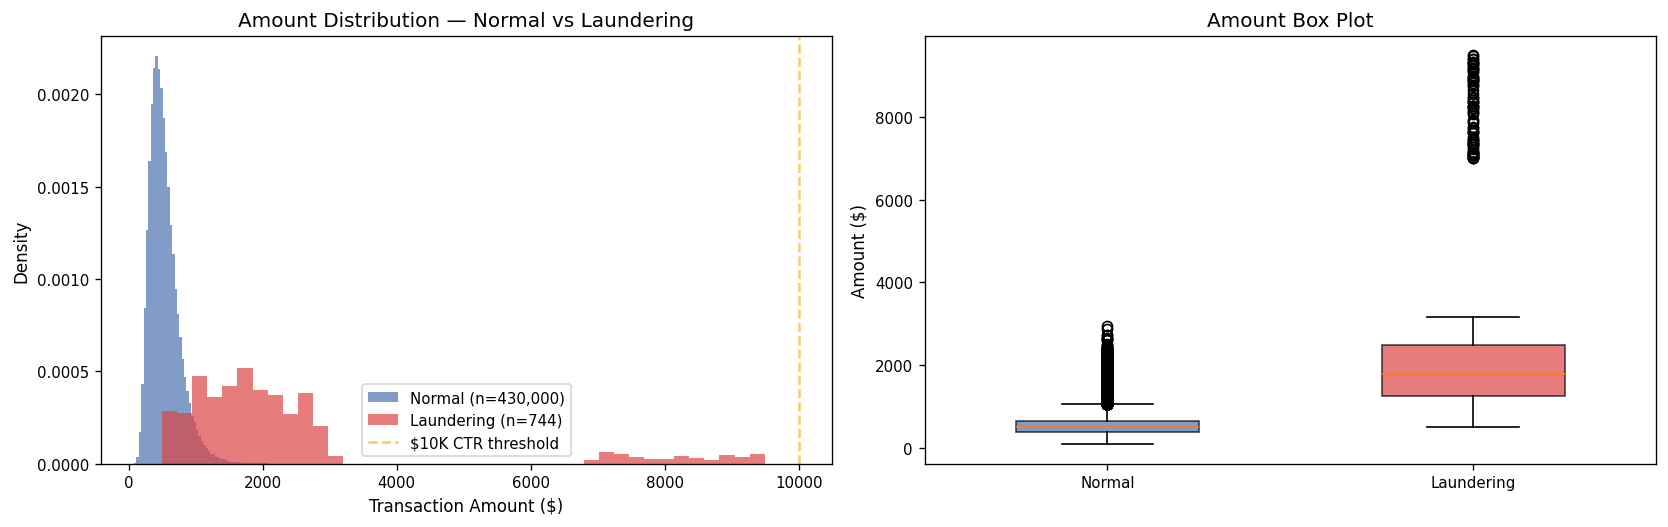

Normal amounts:     mean=$534, median=$493, std=$222
Laundering amounts: mean=$2365, median=$1782, std=$2053
Structuring txns > $7K: 75 (should be ~75 for structuring pattern)


In [11]:
# ── 9a. Amount Distribution: Normal vs Laundering ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

normal_amts = viz_txn.loc[~viz_txn["is_laundering"], "base_amt"]
laun_amts   = viz_txn.loc[viz_txn["is_laundering"], "base_amt"]

# Left: overlaid histogram
axes[0].hist(normal_amts, bins=80, alpha=0.7, color="#4C72B0", label=f"Normal (n={len(normal_amts):,})", density=True)
axes[0].hist(laun_amts, bins=40, alpha=0.7, color="#DD4444", label=f"Laundering (n={len(laun_amts):,})", density=True)
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount Distribution — Normal vs Laundering")
axes[0].legend(fontsize=9)
axes[0].axvline(x=10_000, color="orange", linestyle="--", alpha=0.6, label="$10K CTR threshold")
axes[0].legend(fontsize=9)

# Right: box plots side by side
box_data = [normal_amts.values, laun_amts.values]
bp = axes[1].boxplot(box_data, labels=["Normal", "Laundering"], patch_artist=True, widths=0.5)
bp["boxes"][0].set_facecolor("#4C72B0")
bp["boxes"][1].set_facecolor("#DD4444")
for b in bp["boxes"]:
    b.set_alpha(0.7)
axes[1].set_ylabel("Amount ($)")
axes[1].set_title("Amount Box Plot")

plt.tight_layout()
plt.show()

print(f"Normal amounts:     mean=${normal_amts.mean():.0f}, median=${normal_amts.median():.0f}, std=${normal_amts.std():.0f}")
print(f"Laundering amounts: mean=${laun_amts.mean():.0f}, median=${laun_amts.median():.0f}, std=${laun_amts.std():.0f}")
print(f"Structuring txns > $7K: {(laun_amts > 7000).sum()} (should be ~75 for structuring pattern)")

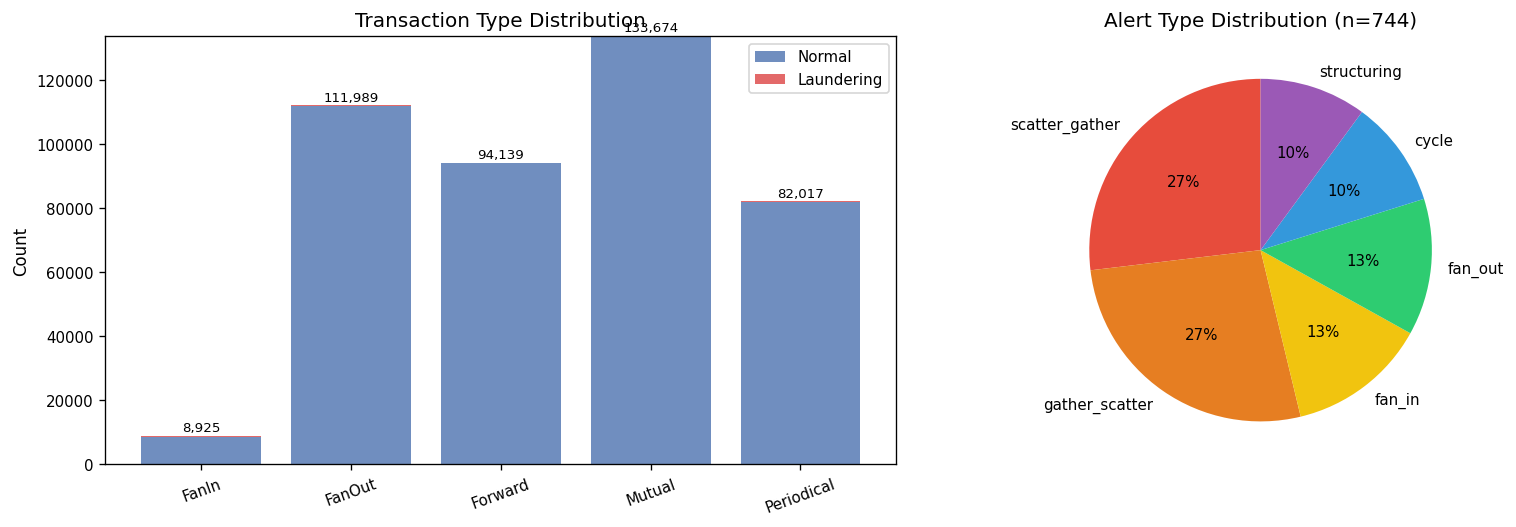

In [12]:
# ── 9b. Transaction Type & Alert Type Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: tx_type bar chart (colored by normal vs laundering contribution)
tx_counts_normal = viz_txn.loc[~viz_txn["is_laundering"], "tx_type"].value_counts()
tx_counts_laun   = viz_txn.loc[viz_txn["is_laundering"], "tx_type"].value_counts()
all_tx_types = sorted(viz_txn["tx_type"].unique())
norm_vals = [tx_counts_normal.get(t, 0) for t in all_tx_types]
laun_vals = [tx_counts_laun.get(t, 0) for t in all_tx_types]
short_labels = [t.replace("TRANSFER-", "") for t in all_tx_types]

bars1 = axes[0].bar(short_labels, norm_vals, color="#4C72B0", alpha=0.8, label="Normal")
bars2 = axes[0].bar(short_labels, laun_vals, bottom=norm_vals, color="#DD4444", alpha=0.8, label="Laundering")
axes[0].set_title("Transaction Type Distribution")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=9)
axes[0].tick_params(axis="x", rotation=20)
# Add count labels
for bar, n, l in zip(bars1, norm_vals, laun_vals):
    total = n + l
    axes[0].text(bar.get_x() + bar.get_width()/2, total + 500, f"{total:,}",
                 ha="center", va="bottom", fontsize=8)

# Right: alert_type pie chart
alert_counts = viz_alert["alert_type"].value_counts()
colors_pie = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#3498DB", "#9B59B6"]
wedges, texts, autotexts = axes[1].pie(
    alert_counts.values, labels=alert_counts.index, autopct="%1.0f%%",
    colors=colors_pie[:len(alert_counts)], startangle=90, textprops={"fontsize": 9}
)
axes[1].set_title(f"Alert Type Distribution (n={len(viz_alert):,})")

plt.tight_layout()
plt.show()

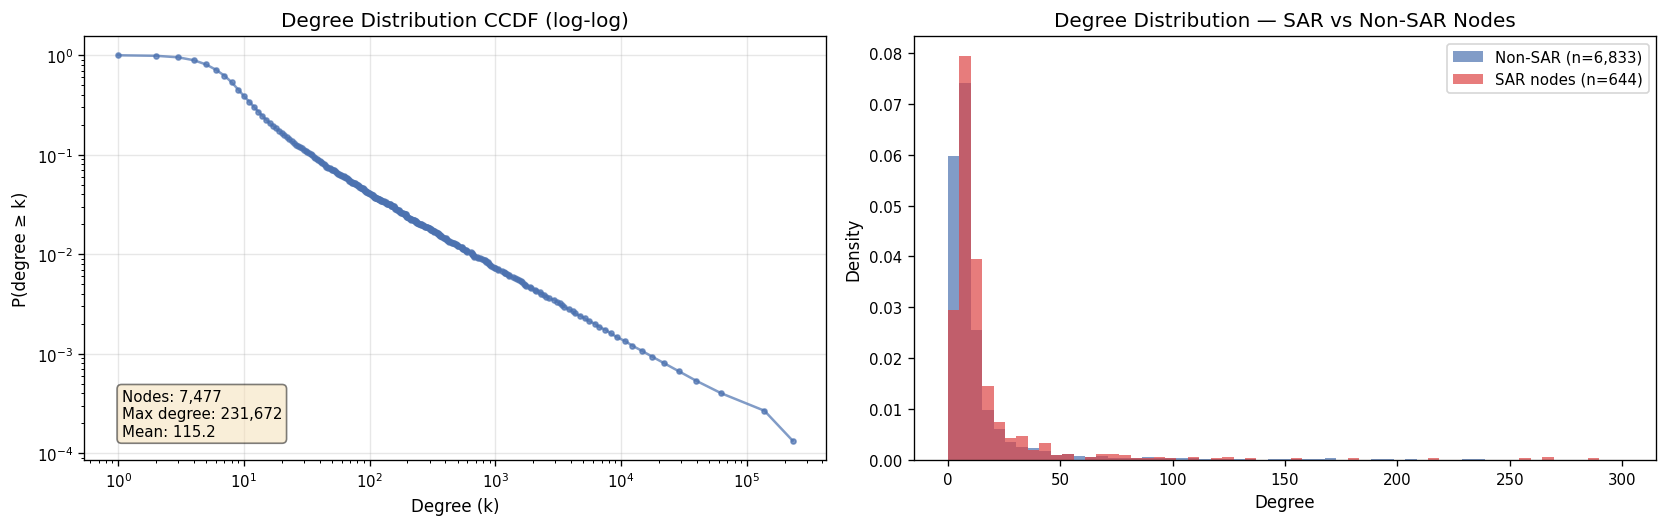

SAR node avg degree: 125.9
Non-SAR avg degree:  114.2
Power-law signature: straight line in log-log CCDF plot (left panel)


In [13]:
# ── 9c. Degree Distribution (log-log scale — should show power-law) ──
# Compute degree per party
src_deg = viz_txn["src"].value_counts()
dst_deg = viz_txn["dst"].value_counts()
total_deg = src_deg.add(dst_deg, fill_value=0).astype(int)

# Separate SAR vs non-SAR nodes
laun_txn_merged = viz_txn.merge(viz_alert[["tran_id"]], on="tran_id", how="inner")
sar_node_ids = set(laun_txn_merged["src"]) | set(laun_txn_merged["dst"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: log-log degree distribution (CCDF)
deg_vals = total_deg.values
deg_count = Counter(deg_vals)
degs = sorted(deg_count.keys())
ccdf = []
n_total = len(deg_vals)
for d in degs:
    ccdf.append(sum(1 for v in deg_vals if v >= d) / n_total)

axes[0].loglog(degs, ccdf, "o-", markersize=3, color="#4C72B0", alpha=0.7)
axes[0].set_xlabel("Degree (k)")
axes[0].set_ylabel("P(degree ≥ k)")
axes[0].set_title("Degree Distribution CCDF (log-log)")
axes[0].grid(True, alpha=0.3)
axes[0].text(0.05, 0.05, f"Nodes: {len(total_deg):,}\nMax degree: {max(deg_vals):,}\nMean: {np.mean(deg_vals):.1f}",
             transform=axes[0].transAxes, fontsize=9, verticalalignment="bottom",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

# Right: histogram of SAR vs non-SAR node degree
sar_degrees = [total_deg.get(n, 0) for n in sar_node_ids if n in total_deg.index]
non_sar_ids = set(total_deg.index) - sar_node_ids
non_sar_degrees = [total_deg[n] for n in non_sar_ids]

bins_deg = np.linspace(0, min(300, max(deg_vals)), 60)
axes[1].hist(non_sar_degrees, bins=bins_deg, alpha=0.7, color="#4C72B0", label=f"Non-SAR (n={len(non_sar_degrees):,})", density=True)
axes[1].hist(sar_degrees, bins=bins_deg, alpha=0.7, color="#DD4444", label=f"SAR nodes (n={len(sar_degrees):,})", density=True)
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Density")
axes[1].set_title("Degree Distribution — SAR vs Non-SAR Nodes")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"SAR node avg degree: {np.mean(sar_degrees):.1f}")
print(f"Non-SAR avg degree:  {np.mean(non_sar_degrees):.1f}")
print(f"Power-law signature: straight line in log-log CCDF plot (left panel)")

/tmp/ipykernel_17146/4129843787.py:31: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly["_month"] = pd.to_datetime(monthly["tran_timestamp"]).dt.to_period("M")


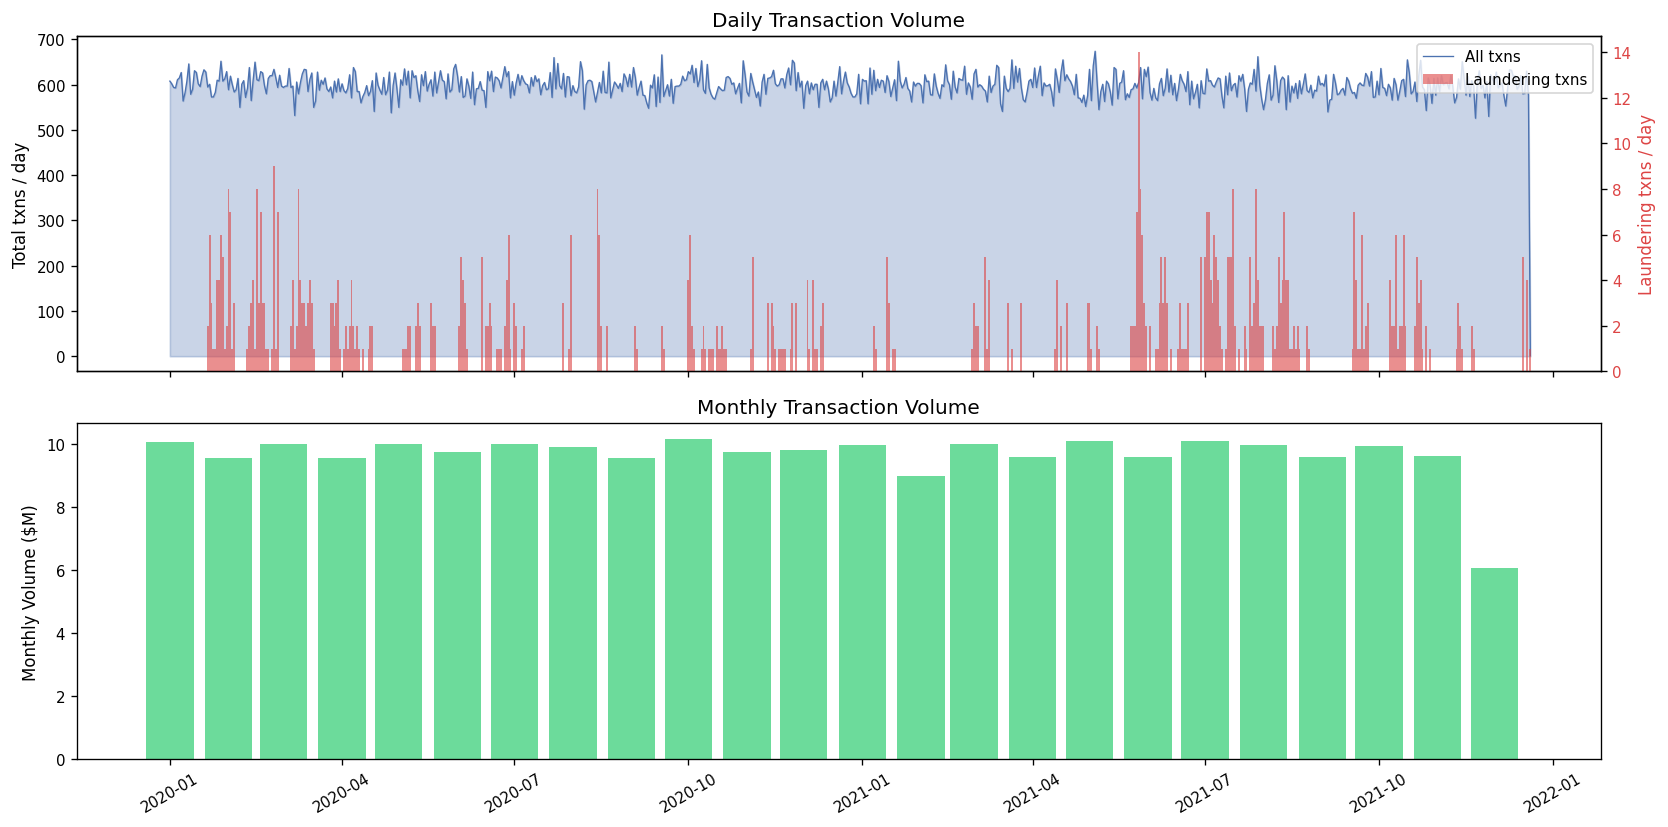

Date range: 2020-01-01 00:00:00 → 2021-12-20 00:00:00
Daily avg: 598 txns/day, $321,224/day


In [14]:
# ── 9d. Transaction Volume Timeline ──
viz_txn["_date"] = pd.to_datetime(viz_txn["tran_timestamp"]).dt.date

# Daily volume
daily = viz_txn.groupby("_date").agg(
    txn_count=("tran_id", "count"),
    total_amt=("base_amt", "sum"),
    laun_count=("is_laundering", "sum"),
).reset_index()
daily["_date"] = pd.to_datetime(daily["_date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: daily txn count
axes[0].fill_between(daily["_date"], daily["txn_count"], alpha=0.3, color="#4C72B0")
axes[0].plot(daily["_date"], daily["txn_count"], color="#4C72B0", linewidth=0.8, label="All txns")
# Overlay laundering
ax_laun = axes[0].twinx()
ax_laun.bar(daily["_date"], daily["laun_count"], color="#DD4444", alpha=0.6, width=1, label="Laundering txns")
ax_laun.set_ylabel("Laundering txns / day", color="#DD4444")
ax_laun.tick_params(axis="y", labelcolor="#DD4444")
axes[0].set_ylabel("Total txns / day")
axes[0].set_title("Daily Transaction Volume")
# Combined legend
h1, l1 = axes[0].get_legend_handles_labels()
h2, l2 = ax_laun.get_legend_handles_labels()
axes[0].legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)

# Bottom: daily total amount
monthly = viz_txn.copy()
monthly["_month"] = pd.to_datetime(monthly["tran_timestamp"]).dt.to_period("M")
monthly_agg = monthly.groupby("_month").agg(
    total_amt=("base_amt", "sum"),
    avg_amt=("base_amt", "mean"),
    txn_count=("tran_id", "count"),
).reset_index()
monthly_agg["_month_dt"] = monthly_agg["_month"].dt.to_timestamp()

axes[1].bar(monthly_agg["_month_dt"], monthly_agg["total_amt"] / 1e6, width=25, color="#2ECC71", alpha=0.7)
axes[1].set_ylabel("Monthly Volume ($M)")
axes[1].set_title("Monthly Transaction Volume")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print(f"Date range: {daily['_date'].min()} → {daily['_date'].max()}")
print(f"Daily avg: {daily['txn_count'].mean():.0f} txns/day, ${daily['total_amt'].mean():,.0f}/day")

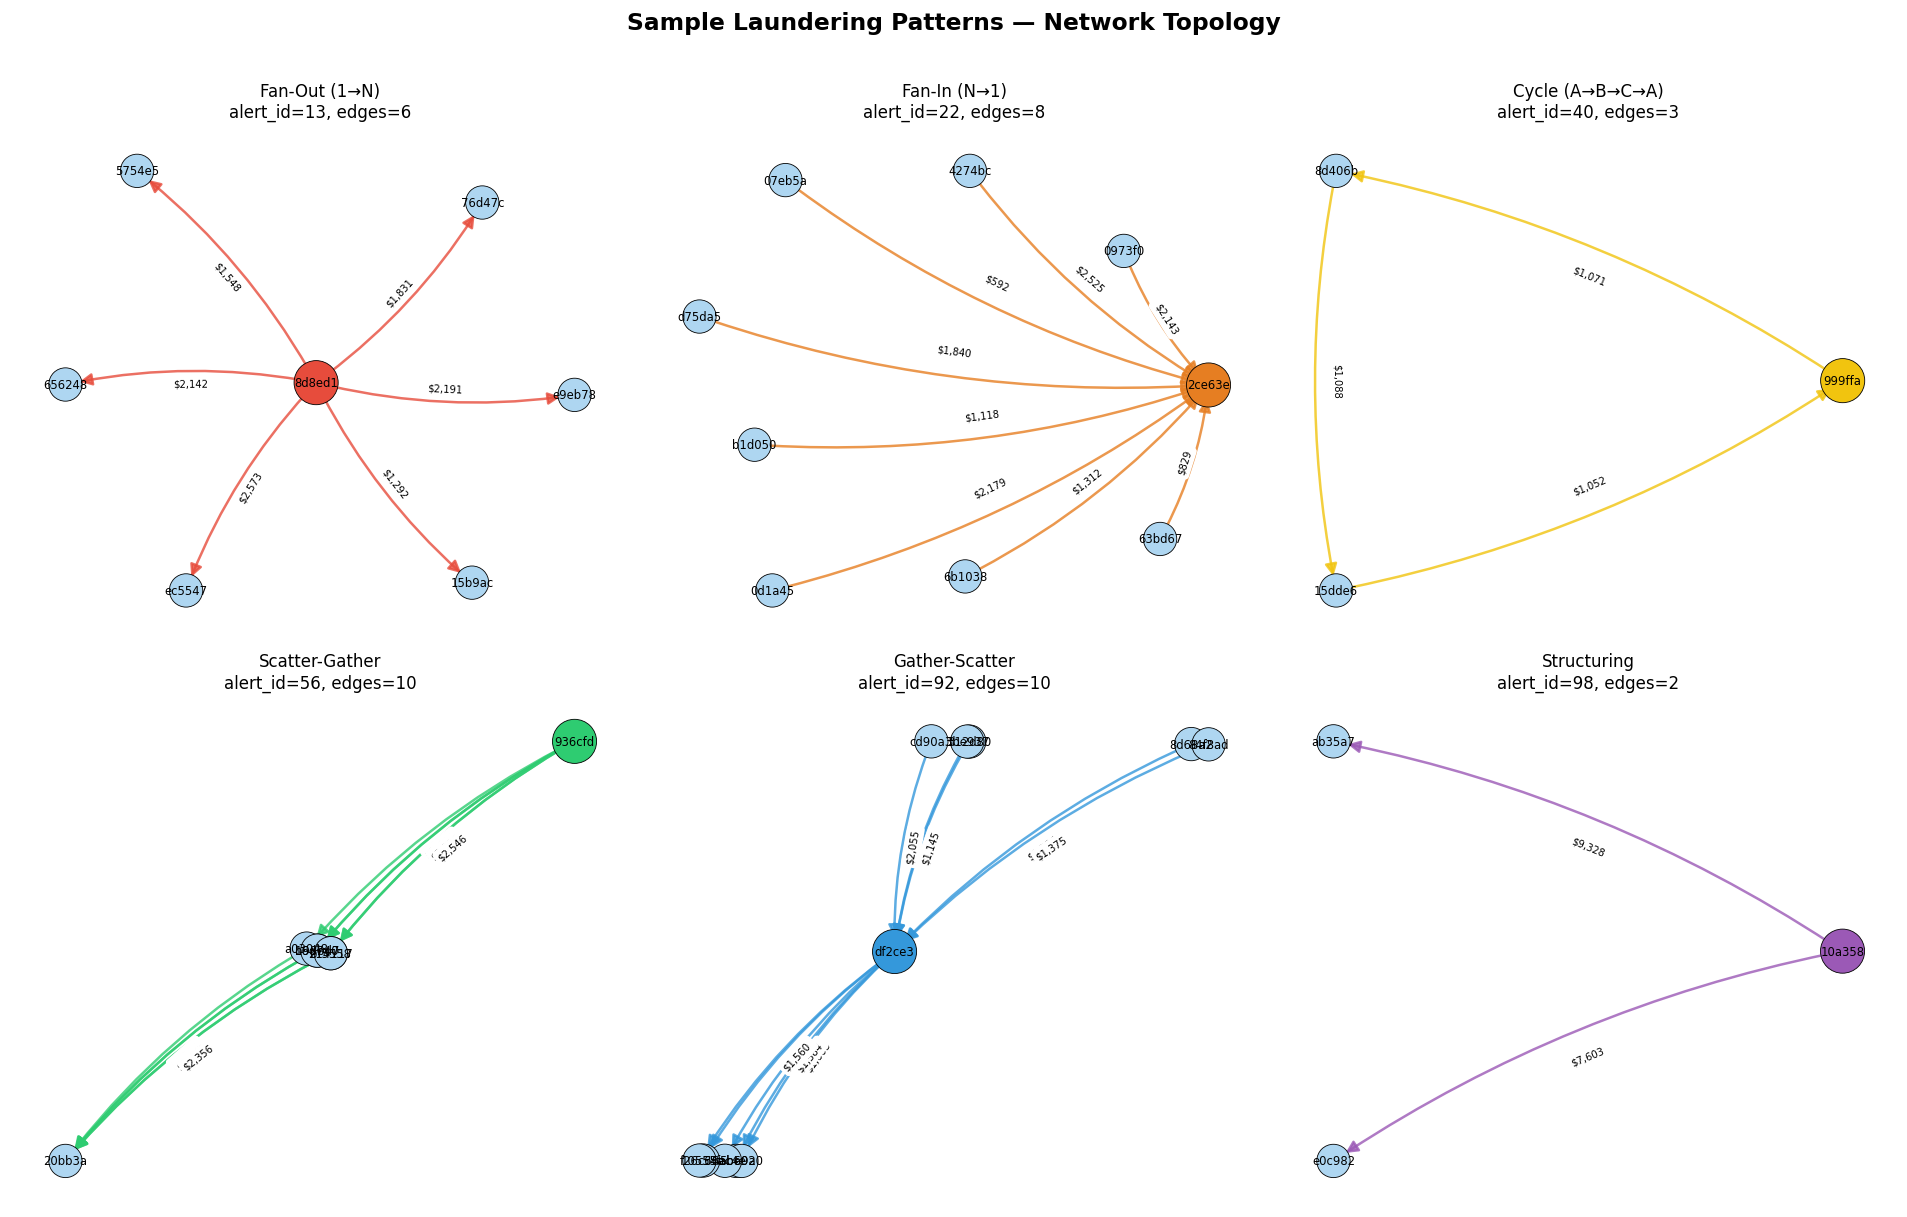

Each panel shows one example of each pattern type extracted from the generated data.
Hub/source node highlighted in pattern color. Arrows show money flow direction.


In [15]:
# ── 9e. Network Graphs of Sample Laundering Patterns ──
# Extract one example of each pattern type and visualize the subgraph

laun_txns = viz_txn.merge(viz_alert[["tran_id", "alert_id", "alert_type"]], on="tran_id", how="inner")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pattern_types = ["fan_out", "fan_in", "cycle", "scatter_gather", "gather_scatter", "structuring"]
pattern_titles = ["Fan-Out (1→N)", "Fan-In (N→1)", "Cycle (A→B→C→A)",
                  "Scatter-Gather", "Gather-Scatter", "Structuring"]
pattern_colors = ["#E74C3C", "#E67E22", "#F1C40F", "#2ECC71", "#3498DB", "#9B59B6"]

for idx, (ptype, title, color) in enumerate(zip(pattern_types, pattern_titles, pattern_colors)):
    ax = axes[idx // 3][idx % 3]
    
    # Pick one alert group of this type
    subset = laun_txns[laun_txns["alert_type"] == ptype]
    if subset.empty:
        ax.set_title(f"{title}\n(no data)")
        ax.axis("off")
        continue
    
    sample_alert_id = subset["alert_id"].iloc[0]
    sample_edges = subset[subset["alert_id"] == sample_alert_id]
    
    # Build directed graph
    G = nx.DiGraph()
    for _, row in sample_edges.iterrows():
        G.add_edge(row["src"][:6], row["dst"][:6], amt=row["base_amt"])
    
    # Color nodes: hub (highest degree) in red, others in light blue
    degrees = dict(G.degree())
    hub_node = max(degrees, key=degrees.get) if degrees else None
    node_colors = [color if n == hub_node else "#AED6F1" for n in G.nodes()]
    node_sizes = [700 if n == hub_node else 400 for n in G.nodes()]
    
    # Layout
    if ptype == "cycle":
        pos = nx.circular_layout(G)
    elif ptype in ("fan_out", "fan_in"):
        pos = nx.spring_layout(G, k=1.5, seed=42)
    else:
        pos = nx.kamada_kawai_layout(G)
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, edgecolors="black", linewidths=0.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=color, arrows=True,
                           arrowsize=15, width=1.5, alpha=0.8,
                           connectionstyle="arc3,rad=0.1")
    
    # Edge labels (amounts)
    edge_labels = {(u, v): f"${d['amt']:,.0f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=6)
    
    ax.set_title(f"{title}\nalert_id={sample_alert_id}, edges={G.number_of_edges()}", fontsize=10)
    ax.axis("off")

plt.suptitle("Sample Laundering Patterns — Network Topology", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Each panel shows one example of each pattern type extracted from the generated data.")
print("Hub/source node highlighted in pattern color. Arrows show money flow direction.")

In [16]:
# ── 9f. Detectability Check — Will case_builder find the patterns? ──
# Verify injected patterns satisfy the detection thresholds from case_builder.py

FAN_RATIO_THRESHOLD = 3.0   # from case_builder.py
CYCLE_MAX_LENGTH = 3         # from case_builder.py
HUB_DOMINANCE_THRESHOLD = 5.0

# Build directed degree from laundering-only edges
laun_edges = laun_txns[["src", "dst", "alert_type"]].copy()
out_deg_laun = laun_edges.groupby(["src", "alert_type"]).size().reset_index(name="out_deg")
in_deg_laun = laun_edges.groupby(["dst", "alert_type"]).size().reset_index(name="in_deg")

check_results = []

# Fan-Out: each hub should have out_degree >= FAN_MIN_LEGS, in_degree = 0 for pattern edges
fo_edges = laun_edges[laun_edges["alert_type"] == "fan_out"]
fo_out = fo_edges["src"].value_counts()
fo_in  = fo_edges["dst"].value_counts()
fo_hubs = fo_out[fo_out >= FAN_MIN_LEGS]
# For hub nodes, ratio = out / (in + 1) → should be >= 3.0
for hub in fo_hubs.index:
    in_d = fo_in.get(hub, 0)
    ratio = fo_hubs[hub] / max(in_d, 1)
    check_results.append(("fan_out", hub[:8], f"out={fo_hubs[hub]}, in={in_d}, ratio={ratio:.1f}", ratio >= FAN_RATIO_THRESHOLD))

# Fan-In: each collector should have in_degree >= FAN_MIN_LEGS
fi_edges = laun_edges[laun_edges["alert_type"] == "fan_in"]
fi_in = fi_edges["dst"].value_counts()
fi_out = fi_edges["src"].value_counts()
fi_hubs = fi_in[fi_in >= FAN_MIN_LEGS]
for hub in fi_hubs.index:
    out_d = fi_out.get(hub, 0)
    ratio = fi_hubs[hub] / max(out_d, 1)
    check_results.append(("fan_in", hub[:8], f"in={fi_hubs[hub]}, out={out_d}, ratio={ratio:.1f}", ratio >= FAN_RATIO_THRESHOLD))

# Cycles: each should have length = 3
cy_edges = laun_edges[laun_edges["alert_type"] == "cycle"]
cy_alerts = laun_txns[laun_txns["alert_type"] == "cycle"]["alert_id"].unique()
for aid in cy_alerts[:5]:  # sample 5
    edges_in_cycle = cy_edges.merge(laun_txns[laun_txns["alert_id"] == aid][["tran_id"]], left_index=True, right_index=True, how="inner")
    n_edges = len(laun_txns[laun_txns["alert_id"] == aid])
    check_results.append(("cycle", f"alert_{aid}", f"edges={n_edges} (need ≤{CYCLE_MAX_LENGTH})", n_edges <= CYCLE_MAX_LENGTH))

# Print results
print("=" * 70)
print("  DETECTABILITY CHECK — Pattern vs case_builder.py Thresholds")
print("=" * 70)
print(f"{'Pattern':<18} {'Entity':<12} {'Metrics':<40} {'Pass?'}")
print("-" * 70)
for ptype, entity, metrics, passed in check_results:
    status = "PASS" if passed else "FAIL"
    print(f"{ptype:<18} {entity:<12} {metrics:<40} {status}")

n_pass = sum(1 for _, _, _, p in check_results if p)
n_total = len(check_results)
print(f"\n  {n_pass}/{n_total} checks passed")
print(f"  Fan-out hubs detectable: {len(fo_hubs)}/{NUM_FAN_OUT}")
print(f"  Fan-in hubs detectable:  {len(fi_hubs)}/{NUM_FAN_IN}")
print(f"  Cycles with length ≤ {CYCLE_MAX_LENGTH}: {len(cy_alerts)}/{NUM_CYCLE}")

  DETECTABILITY CHECK — Pattern vs case_builder.py Thresholds
Pattern            Entity       Metrics                                  Pass?
----------------------------------------------------------------------
fan_out            f7bbd242     out=8, in=0, ratio=8.0                   PASS
fan_out            8a868ae3     out=8, in=0, ratio=8.0                   PASS
fan_out            15c20991     out=8, in=0, ratio=8.0                   PASS
fan_out            f5f917ec     out=7, in=0, ratio=7.0                   PASS
fan_out            da14d964     out=7, in=0, ratio=7.0                   PASS
fan_out            34c65a01     out=7, in=0, ratio=7.0                   PASS
fan_out            267b9706     out=7, in=0, ratio=7.0                   PASS
fan_out            d5bdeac3     out=7, in=0, ratio=7.0                   PASS
fan_out            8d8ed182     out=6, in=0, ratio=6.0                   PASS
fan_out            037853d1     out=6, in=0, ratio=6.0                   PASS
fan_out 

In [ ]:
# ── 9g. Simulation Quality Scorecard ──
# Final pass/fail summary across all quality dimensions

sar_rate = len(sar_node_ids) / len(viz_party) * 100
avg_deg = len(viz_txn) / len(viz_party)

checks = {
    "Party count (7,000–8,000)":       7_000 <= len(viz_party) <= 8_000,
    "Transaction count (>400K)":        len(viz_txn) > 400_000,
    "SAR rate (5–15%)":                 5.0 <= sar_rate <= 15.0,
    "Mean amount ($400–$700)":          400 <= viz_txn["base_amt"].mean() <= 700,
    "No self-loops":                    (viz_txn["src"] != viz_txn["dst"]).all(),
    "All src/dst in party.csv":         len(set(viz_txn["src"]) - set(viz_party["partyId"])) == 0,
    "All alert tran_ids valid":         len(set(viz_alert["tran_id"]) - set(viz_txn["tran_id"])) == 0,
    "No duplicate tran_ids":            not viz_txn["tran_id"].duplicated().any(),
    "All 6 pattern types present":      len(viz_alert["alert_type"].unique()) == 6,
    "Power-law degree (max > 10x avg)": total_deg.max() > 10 * total_deg.mean(),
    "Date range spans >1 year":         (pd.to_datetime(viz_txn["tran_timestamp"]).max() - pd.to_datetime(viz_txn["tran_timestamp"]).min()).days > 365,
    "Structuring amounts < $10K":       laun_amts.max() < 10_000,
}

print("=" * 60)
print("  SIMULATION QUALITY SCORECARD")
print("=" * 60)
all_pass = True
for name, passed in checks.items():
    icon = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{icon}]  {name}")

print("-" * 60)
if all_pass:
    print("  ALL CHECKS PASSED — simulation data is ready for pipeline")
else:
    print("  SOME CHECKS FAILED — review above before proceeding")
print("=" * 60)
print(f"\n  Next step: run e2e/01_data_loading_and_features.ipynb")
print(f"  Data location: {os.path.abspath(OUTPUT_DIR)}")

  SIMULATION QUALITY SCORECARD
  [PASS]  Party count (7,000–8,000)
  [PASS]  Transaction count (>400K)
  [PASS]  SAR rate (5–15%)
  [PASS]  Mean amount ($400–$700)
  [PASS]  No self-loops
  [PASS]  All src/dst in party.csv
  [PASS]  All alert tran_ids valid
  [PASS]  No duplicate tran_ids
  [PASS]  All 6 pattern types present
  [PASS]  Power-law degree (max > 10x avg)
  [PASS]  Date range spans >1 year
  [PASS]  Structuring amounts < $10K
------------------------------------------------------------
  ALL CHECKS PASSED — simulation data is ready for pipeline

  Next step: run e2e/01_data_loading_and_features.ipynb
  Data location: /home/adnoman/projects/aml_gan/amle2e/demodata


: 